# Property Price Model Comparison

In this notebook, we evaluate and compare four different modelling architectures for predicting real estate prices in Malmö:
1. **ElasticNet** (Regularised Linear Regression baseline)
2. **Random Forest** (Simple tree-based baseline)
3. **LightGBM** (Gradient Boosted Trees)
4. **CatBoost** (Gradient Boosted Trees with native categorical handling)

We use `HalvingRandomSearchCV` for an efficient parameter search, and compare results across **R², MAE, MAPE**, and measure both **training time** and **inference time**.
Finally, we contrast the **feature importances** extracted by the tree-based models.

In [7]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from src.features.build_features import load_data, prepare_xy
from src.models.evaluate_models import get_model_configs, evaluate_model

%matplotlib inline
sns.set_theme(style="whitegrid", palette="deep")

### 1. Data Loading & Feature Engineering

In [8]:
# Load processed parquet batches from data/processed/
df_raw = load_data("../")

# Create final feature matrix and ordinal encode the categoricals
X, y, encoder, feature_names = prepare_xy(df_raw)

print(f"Dataset dimensions: {X.shape}")
display(X.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Dataset dimensions: (56646, 11)


,rooms,living_area,association_fee,building_year,latitude,longitude,sale_year,sale_month,neighborhood,housing_type,ownership_type
0,1.0,26.5,1436.0,1961.0,55.591446,12.964134,2013.0,12.0,322.0,0.0,3.0
1,1.0,23.5,1642.0,1955.0,55.589740,13.012270,2024.0,11.0,804.0,0.0,3.0
2,1.0,26.0,1986.0,2014.0,55.610706,12.977838,2023.0,1.0,1388.0,0.0,3.0
3,1.0,20.5,2566.0,1945.0,55.597336,12.973068,2022.0,4.0,1098.0,0.0,3.0
4,1.0,25.5,1527.0,1972.0,55.577285,12.988886,2021.0,10.0,1257.0,0.0,3.0


### 2. Splitting Data

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train samples: {len(X_train)} | Test samples: {len(X_test)}")

Train samples: 45316 | Test samples: 11330


### 3. Model Tuning & Benchmarking
Using `HalvingRandomSearchCV` across our model architectures.

In [10]:
configs = get_model_configs(random_state=42)
results = {}

for name, config in configs.items():
    print(f"\n{'='*50}")
    print(f"Evaluating {name}...")
    res = evaluate_model(
        name=name,
        estimator=config["estimator"],
        param_grid=config["param_grid"],
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        random_state=42,
        cv_folds=3  # Reduced folds for notebook exploration speed
    )
    results[name] = res


Evaluating ElasticNet...

Evaluating RandomForest...

Evaluating LightGBM...

Evaluating CatBoost...


### 4. Performance Comparison

In [11]:
metrics_df = pd.DataFrame([{
    "Model": name,
    "R²": r["r2"],
    "MAE (SEK)": r["mae"],
    "MAPE (%)": r["mape"],
    "Train Time (s)": r["train_time_sec"],
    "Infer Time / 1k samples (ms)": r["infer_time_per_1k_ms"]
} for name, r in results.items()])

metrics_df = metrics_df.sort_values("MAE (SEK)").reset_index(drop=True)
display(metrics_df.round(3))

,Model,R²,MAE (SEK),MAPE (%),Train Time (s),Infer Time / 1k samples (ms)
0,CatBoost,0.923,216676.359,11.101,388.219,19.766
1,LightGBM,0.912,234057.312,12.154,548.227,2.324
2,RandomForest,0.903,250786.112,13.343,71.888,36.549
3,ElasticNet,0.514,628785.227,38.114,26.699,0.190


### 5. Feature Importances
Comparing what features each Tree-based model relies on.

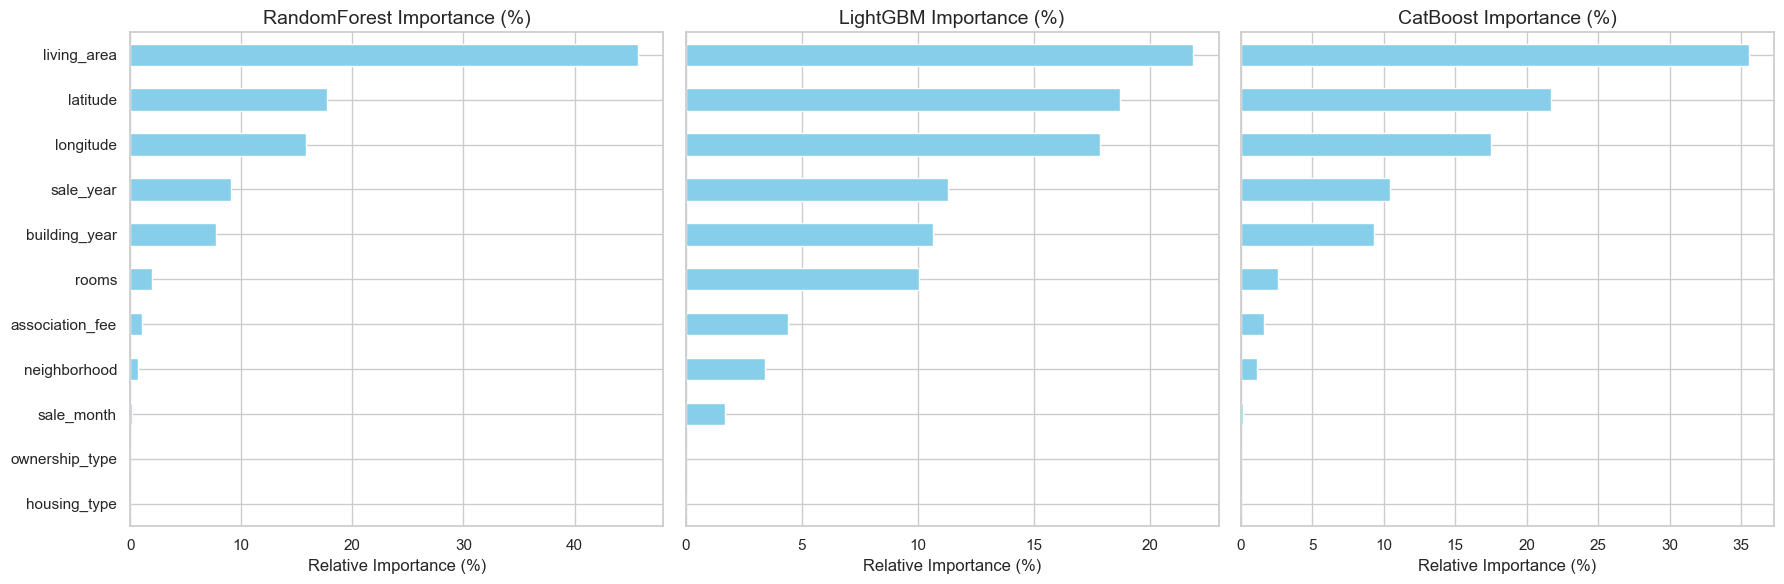

In [12]:
tree_models = ["RandomForest", "LightGBM", "CatBoost"]
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, model_name in zip(axes, tree_models):
    importances = results[model_name]["feature_importances"]
    if not importances:
        continue
    
    imp_df = pd.Series(importances).sort_values(ascending=True)
    
    # Normalize to 100% for fair comparison scale across different native implementations
    imp_df = (imp_df / imp_df.sum()) * 100
    
    imp_df.plot(kind='barh', ax=ax, color='skyblue')
    ax.set_title(f"{model_name} Importance (%)", fontsize=14)
    ax.set_xlabel("Relative Importance (%)")

plt.tight_layout()
plt.show()